## Geomodeling benchmark: the “Hecho”-Model
- This model is part of a geomodeling benchmaring effort

In [1]:
import geoinr_faults as grf

Define the model conditions

In [2]:
geomodel = grf.create_geomodel(
    project_name='Hecho',
    extent=[0, 16, -0.5, 0.5, 0, 4.5],
    resolution=[200, 50, 100],
    path_to_surface_points='input_data/Hecho/Hecho_interface.csv',
    #path_to_orientations='input_data/Hecho/Hecho_orientation.csv',
)

In [3]:
geomodel

GeoModel('Hecho', extent=[0, 16, -0.5, 0.5, 0, 4.5], resolution=[200, 50, 100], stratis=0, horizons=[], faults=0)

Add stratigraphy column

In [4]:
geomodel = grf.add_stratis(geomodel, strati_configs=[
    grf.StratiConfig(name="Hecho_main", formations=['layer1', 'layer2', 'layer3', 'layer4', 
                                                    'layer5', 'layer6', 'layer7', 'layer8', 'layer9'],),
])

In [5]:
geomodel

GeoModel('Hecho', extent=[0, 16, -0.5, 0.5, 0, 4.5], resolution=[200, 50, 100], stratis=1, horizons=[9], faults=0)

[warn] No orientation points/vectors found; orientation visualization skipped.


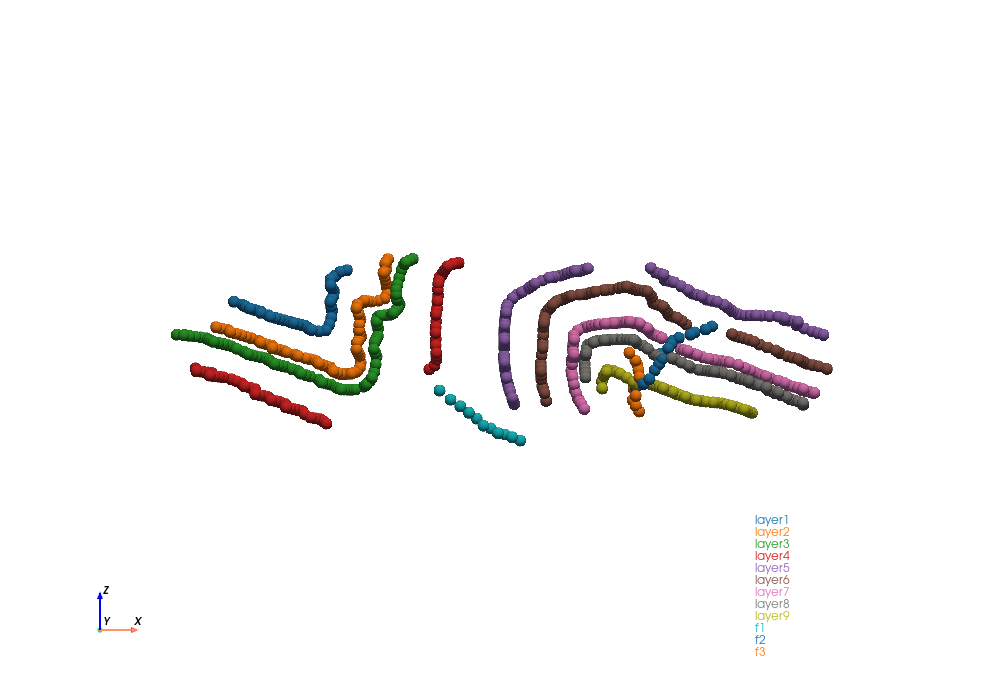

In [6]:
grf.plot_input_data(geomodel, notebook=True, legend_size=(0.22, 0.22))

Add faults, here the fault trunction rules are used, if `truncation` is true, need to define the truncting fault

In [7]:
geomodel = grf.add_faults(geomodel, fault_configs=[
    grf.FaultConfig(name='f1', lx=5, ly=1.4, lz=2,
                   dmax=1, lam=0.5, Normal_fault=True),
    grf.FaultConfig(name='f3', lx=5, ly=0.9, lz=2,
                   dmax=1, lam=0.5, Normal_fault=False), 
    grf.FaultConfig(name='f2', lx=5, ly=1.4, lz=2,
                   dmax=1, lam=0.5, Normal_fault=False,
                   truncation=True, trunc_fault_name='f3',
                   hanging_trunc=False), 
])

In [8]:
geomodel

GeoModel('Hecho', extent=[0, 16, -0.5, 0.5, 0, 4.5], resolution=[200, 50, 100], stratis=1, horizons=[9], faults=3)

Visualization of fault feature fields

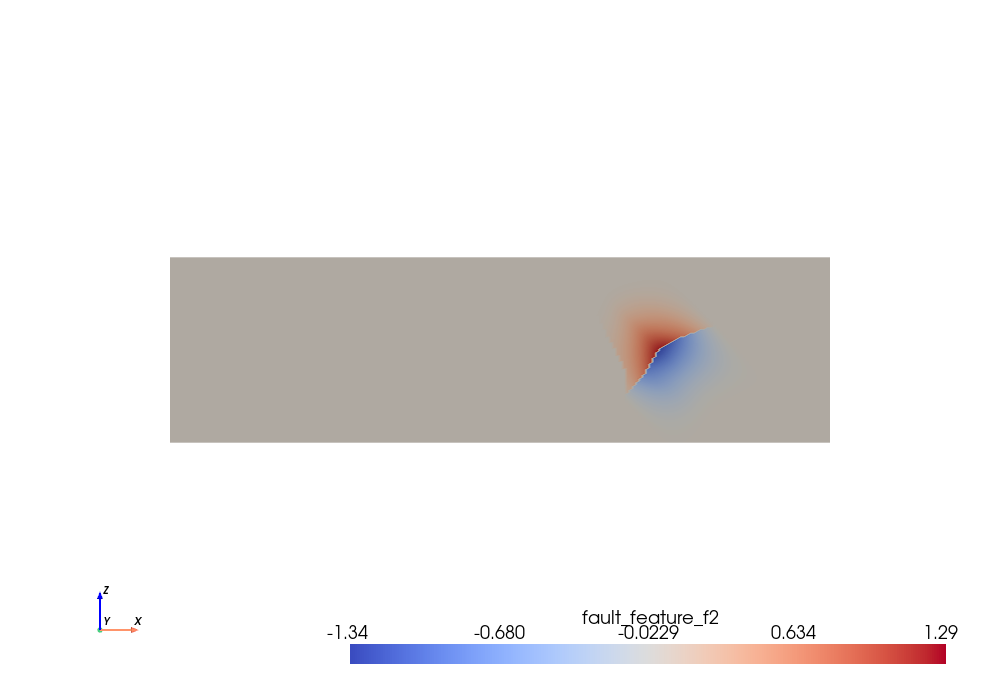

In [9]:
grf.plot_fault_features(geomodel, fault_name='f2', cmap='coolwarm', notebook=True)

Visualizing fault surfaces

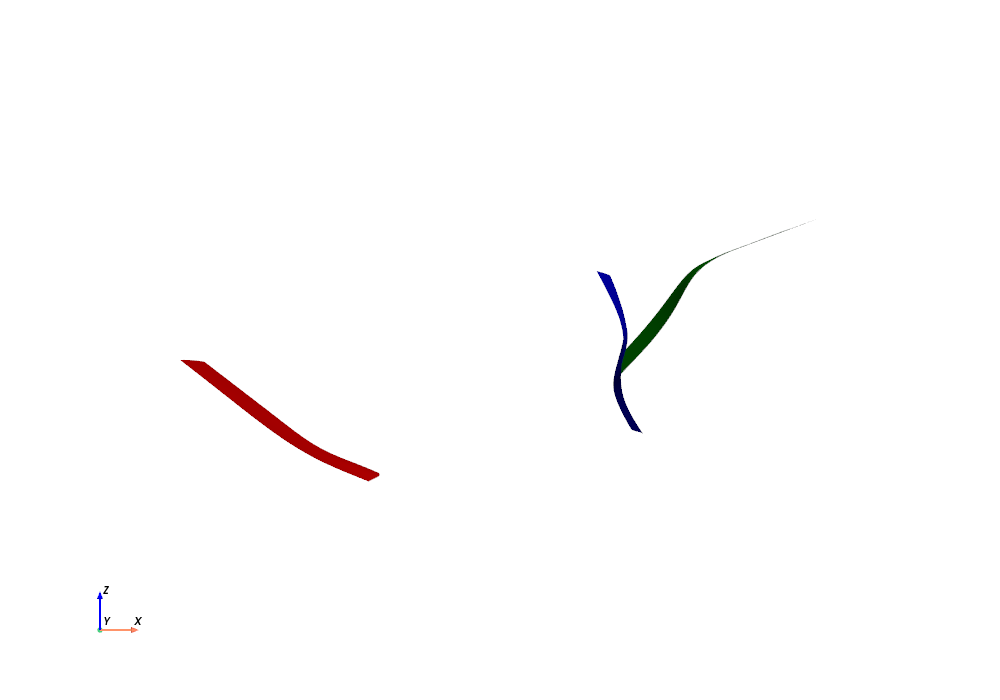

In [10]:
grf.plot_fault_meshes(geomodel, notebook=True)

Compute model

In [11]:
results = grf.compute_model(
    geomodel,
    nn_model='mlp',          # 'mlp' | 'siren' | 'resnet'  or custom class
    hidden_dim=512,
    n_layers=2,
    activation='softplus',   # 'softplus' | 'relu' | 'tanh' | 'sine' | ...
    softplus_beta=50,
    epochs=2000,
    lr=1e-3,
    #seed=202507,
)

Epoch [500/2000]  Loss: 0.0873  Var: 0.0004  On: 0.0869  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0809
Epoch [1000/2000]  Loss: 0.0520  Var: 0.0003  On: 0.0517  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0520
Epoch [1500/2000]  Loss: 0.0517  Var: 0.0004  On: 0.0513  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0411
Epoch [2000/2000]  Loss: 0.0396  Var: 0.0004  On: 0.0393  Above: 0.0000  Below: 0.0000  Orie: 0.0000  Best: 0.0330

Training finished in 41.3 s  |  Best loss: 0.0330
Inference completed in 0.0070 s


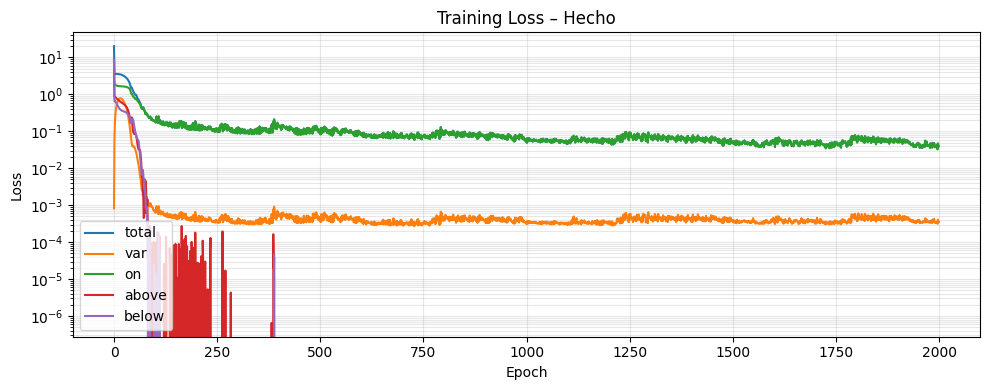

In [12]:
grf.plot_loss(results)

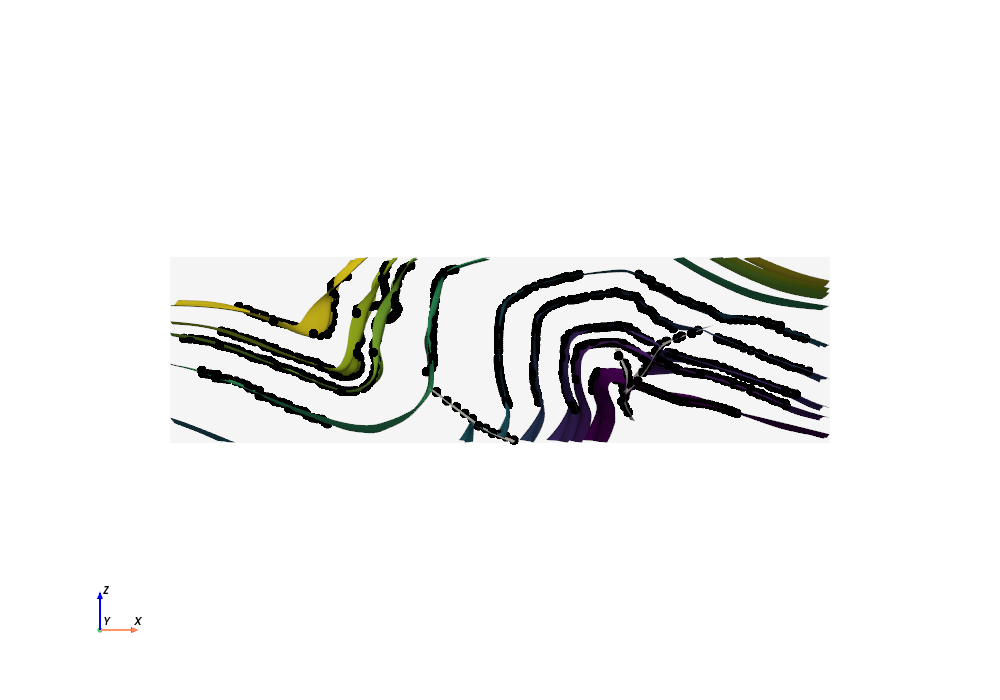

In [13]:
grf.plot_model(results, notebook=True, show_scalar_field=False, show_isosurfaces=True, camera_position='xz', show_fault_meshes=True, show_points=True)

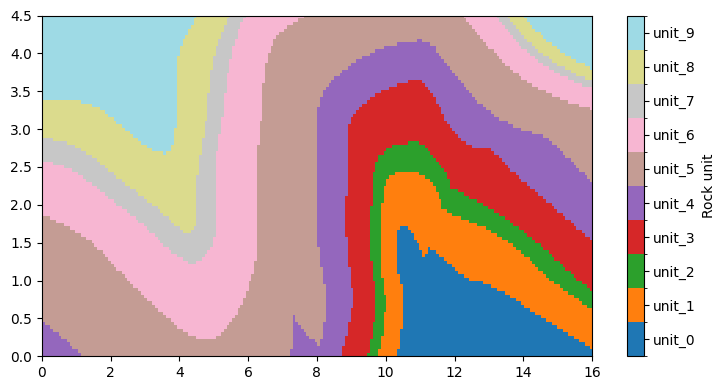

In [14]:
grf.plot_section_rock_unit(results, axis='y',figsize=(7.5, 4))